<a href="https://colab.research.google.com/github/Adeela-saleem/MachineLearning_Algorithms/blob/main/Supervised_Learning/Regression/PolynomialRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#polyniomial --> non-liner data ko linear model ki rtick sy fit krna

Polynomial Regression ke peeche ki **Intuition (Dimaagi Soch)** aur **Mathematical Logic** boht simple hai. Aapko yeh samajhne mein dushwari isliye ho rahi hai kyunki aap soch rahe hain ke "powers add karne se magic kaise ho gaya?".

Aayein isey simple real-world logic aur math se samajhte hain:

---

### 1. Simple Intuition: Seedhi Line vs Curve

Jab aap normal **Linear Regression** chalate hain, toh model ka formula hota hai:


$$y = \beta_0 + \beta_1 X$$

* **Problem:** Yeh formula math mein **Sirf aur Sirf Ek Seedhi Line (Straight Line)** hi draw kar sakta hai. Isme itni taaqat hi nahi hai ke yeh bend (mure) ho sake.
* **Real-World Example:** Sochye ek car ki speed aur uske brake lagane par rukne ka distance.
* Speed $20$ km/h ho toh rukhne mein $5$ meters lagte hain.
* Speed $40$ km/h (double) ho, toh stopping distance $10$ meter nahi balki $20$ meters (chaar guna) ho jata hai, kyunki Kinetic Energy ka formula $E = \frac{1}{2} m v^2$ hota hai!
* Real life mein relationships often **Square ($X^2$)** ya **Cube ($X^3$)** ke hisab se badhte hain, linear nahi.



---

### 2. Prove Kaise Hua Ke $X^2$ Add Karne Se Model Behtar Hoga?

Mathematically, jab hum $X^2$ add karte hain, toh new equation banti hai:


$$y = \beta_0 + \beta_1 X + \beta_2 X^2$$

Yeh Quadratic Equation (Parabola) ka formula hai.

#### Model Ko Flexible Banana:

1. **Model Flexible Ho Jata Hai:**
* Agar data linear **hua** (yani bend nahi hai), toh model smart hai! Model training ke waqt **$\beta_2 = 0$** kar dega. Equation automatic wapas $y = \beta_0 + \beta_1 X$ ban jayegi.
* Agar data **curved hua**, toh model $\beta_2$ ko koi value (jaise $3.5$) de dega, jis se line bend ho kar curved dots ko touch karne lagegi.


2. **Error (Loss) Kam Hota Hai:**
* Pure linear line curved data ke saare points ko miss karti hai, jis se **Mean Squared Error (MSE) boht high** aata hai.
* Curved line saare points ke boht qareeb se guzarti hai, jis se **MSE boht kam** ho jata hai aur $R^2$ score jump kar jata hai. Yahi iska proof hai ke model perform kar raha hai.



---

### 3. Asli Trick: Linear Math Se Non-Linear Line Fitting

Scikit-Learn ka `LinearRegression()` algorithm ab bhi pure linear algebra hi chala raha hai.

* Model ke liye:
* Column 1 ($X$) = Feature 1
* Column 2 ($X^2$) = Feature 2 (Model ko nahi pata ke yeh $X$ ka square hai, woh isey alag feature hi samajhta hai!)



Model background mein **Multiple Linear Regression** hi run karta hai:


$$y = \beta_0 + \beta_1 (F_1) + \beta_2 (F_2)$$

Lekin jab hum isey 2D graph par plot karte hain, toh $F_2 = X^2$ hone ki wajha se graph par **Seedhi Line Bend Ho Kar Smooth Curve Ban Jati Hai**.

---

### Markdown Summary (For Notebook)

```markdown
### **Intuition Behind Polynomial Regression**

1. **Why Linear Model Fails:**
   * Standard Linear Regression ($y = \beta_0 + \beta_1 X$) can ONLY draw a straight line. It lacks the degree of freedom to bend or fit non-linear patterns.

2. **The Power Trick ($X^2, X^3$):**
   * By creating power features ($X^2$), we convert the linear equation into a parabola ($y = \beta_0 + \beta_1 X + \beta_2 X^2$).
   * This gives the model the mathematical capability to create curves and match real-world relationships (like area, acceleration, or non-linear growth).

3. **How It Is Proven To Be Better:**
   * **Flexibility:** If the data is actually linear, the model sets $\beta_2 \approx 0$. If curved, $\beta_2$ adjusts to capture the bend.
   * **Error Reduction:** Adding polynomial features significantly reduces Mean Squared Error (MSE) and boosts the $R^2$ score by aligning the curve directly with the data points.

```

**### that's my understanding :**

 ye confusion hai ..for example  hmary ps 1 input hai 1 output kind of linear model but inka relation lineear nhi hai to hm polynomial lga  rhy ab is sy kya hog k 1 or feature extra ad hojayg jb 2 hogaye obv multile lr ki categortme jayga or bias term bh ad hogi phir is pr mlr ka odel chlyga but q k ye squared hai to line linear nhi curve bnti jaygi ?

$$\text{Formula: } y = a X^2 + b X + c + \text{noise}$$

### **Data Generation Insights**

1. **Feature Range Choice:**
   * Range selection (e.g., $[-3, 3]$) is flexible. Centering around zero ensures symmetrical visualization of both sides of the parabola curve.

2. **Coefficients Selection ($a, b, c$):**
   * During synthetic dataset generation, equation coefficients ($y = aX^2 + bX + c$) are user-defined constants used to establish a ground-truth pattern.
   * In real-world applications, these true parameters are unknown, and Machine Learning models aim to estimate them from observed data.

finally--let'sstart

In [2]:
import numpy as np

In [3]:
X=6*np.random.rand(200,1)-3  #cuz rand gives numbers bw 0.0 se 1.0
y=0.5*X**2+X+2+np.random.randn(200,1)


In [4]:
import matplotlib.pyplot as plt

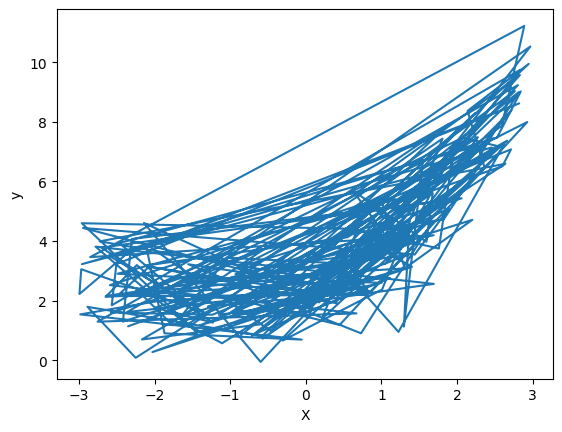

In [5]:
plt.plot(X,y )
plt.xlabel("X")
plt.ylabel("y")
plt.show()

### **Fixing Unsorted Plot Issue (`plt.plot` vs `plt.scatter`) Summary**

1. **Root Cause:**
* `plt.plot(X, y)` connects consecutive data points with line segments. Because `X` contains unordered, random values, the rendering line criss-crosses back and forth across the plot space, producing a tangled "spider-web" effect.


2. **Resolution Options:**
* **Use Scatter Plot (Recommended):** Replace `plt.plot(X, y)` with `plt.scatter(X, y)` to render distinct data points without connecting lines.
* **Format Option in `plt.plot`:** Use `plt.plot(X, y, 'b.')` to draw individual blue dots instead of connected lines.


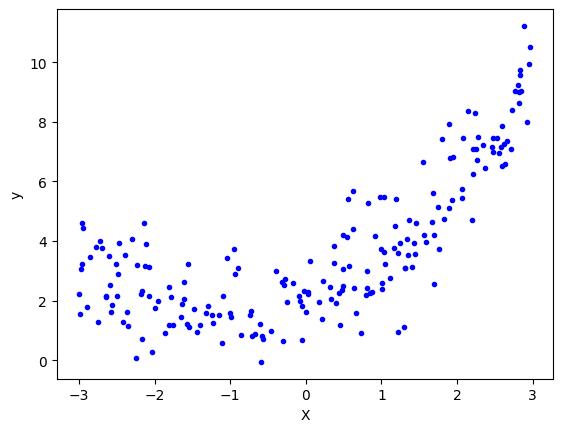

In [6]:
plt.plot(X,y,'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [7]:
#train test split
X_train,X_test,y_train,y_test=X[:120],X[120:],y[:120],y[120:]

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
# Applying linear regression
lr = LinearRegression()

In [10]:

lr.fit(X_train,y_train)

LinearRegression()

In [11]:
y_pred = lr.predict(X_test)


In [12]:
from sklearn.metrics import mean_squared_error,r2_score

In [13]:
r2_score(y_test,y_pred)


0.44001881296641454

In [14]:
mean_squared_error(y_test,y_pred)

2.9011739998655606

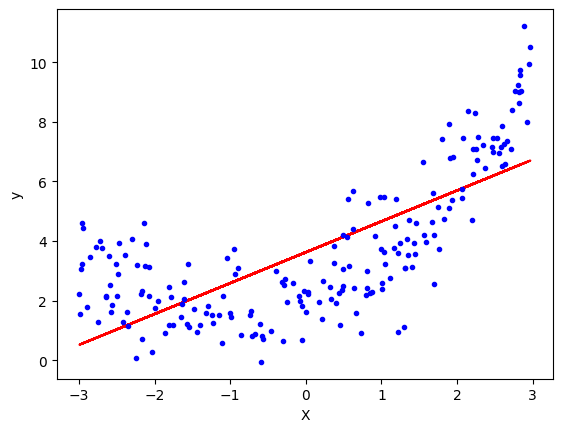

In [15]:
plt.plot(X_train,lr.predict(X_train),color='r')
plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

### **Polynomial Regression vs. Simple Linear Regression**

#### **1. Analysis of Simple Linear Model Baseline**
* **Linear Model Performance:**
  * Test $R^2$ Score: **~0.50**
  * Mean Squared Error (MSE): **~2.74**
* **Visualization Findings:**
  * Fitting a standard `LinearRegression()` model on non-linear data results in a straight red line cutting through a parabolic (U-shaped) distribution of data points.
  * The straight line fails to capture the underlying curvature, leading to high residuals (errors) across both ends of the input range.

---

#### **2. Why Simple Linear Regression Fails Here (Underfitting)**
* **Structural Limitation:** A degree-1 linear model ($y = \beta_0 + \beta_1 X$) only has 1 slope parameter, restricting its hypothesis space strictly to straight lines.
* **Underfitting Diagnosis:** Because the model lacks the functional capacity to represent curves, it **underfits** the data, yielding low accuracy on both training and test sets.

---

#### **3. The Polynomial Solution (`PolynomialFeatures`)**
* **Core Idea:** Transform input features into higher-degree polynomials before passing them to the linear estimator.
* **Algebraic Mechanism:**
  $$\text{Original Feature: } [X] \xrightarrow{\text{PolynomialFeatures(degree=2)}} [1, X, X^2]$$
* **Why It Works:**
  * Model equation transitions to Multiple Linear Regression (MLR):
    $$y = \beta_0 + \beta_1 X + \beta_2 X^2$$
  * While the optimization math remains linear with respect to parameters ($\boldsymbol{\beta}$), the resulting decision boundary/prediction line bends smoothly into a curve, drastically increasing model capacity and boosting the $R^2$ score.


## Applying Polynomial Linear Regression
# degree 2 cuz we've quadratic formula and highest power is 2

In [16]:
from sklearn.preprocessing import PolynomialFeatures

In [17]:
poly=PolynomialFeatures(degree=2, include_bias=True)

Parameter Setting,Feature Matrix,Linear Regression Behavior
include_bias=True,"[1,X,X2]",1s ka column matrix ke andar include hota hai.
include_bias=False,"[X,X2]",Clean features hote hain; Intercept model khud fit karta hai.

In [18]:
X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)


### **Feature Transformation Mechanism (`fit_transform` vs `transform`)**

1. **`poly.fit_transform(X_train)`:**
   * Calculates the feature mapping rules on $X_{train}$ and generates polynomial features ($X \to [X, X^2]$).

2. **`poly.transform(X_test)`:**
   * Applies the exact pre-learned transformation parameters to $X_{test}$ without re-fitting.

3. **Data Leakage Prevention:**
   * Using `.fit()` on test data leaks test set distribution info into the preprocessing pipeline. Always use `transform()` on evaluation/test sets.

In [19]:
print(X_train[0])
print(X_train_trans[0])

[2.58736413]
[1.         2.58736413 6.69445315]


In [20]:
from sklearn.linear_model import LinearRegression

In [21]:
lr = LinearRegression()
lr.fit(X_train_trans,y_train)

LinearRegression()

In [22]:
y_pred = lr.predict(X_test_trans)

In [23]:
r2_score(y_test,y_pred)


0.7341520570413432

In [24]:
print(lr.coef_)
print(lr.intercept_)

[[0.         1.05970504 0.49218541]]
[2.04705167]


fit_transform (Transformer Class):

Yeh PolynomialFeatures, StandardScaler, vagaira par chalta hai.

Unka kaam data ka shape ya structure badalna hota hai.

.fit() (Estimator / Model Class):

Scikit-Learn mein LinearRegression() ek Model (Estimator) hai, Transformer nahi.

Model ka kaam data ka structure badalna nahi, balki data se maths/weights sikhna hota hai. Isliye is par sirf .fit() aur .predict() chalta hai.

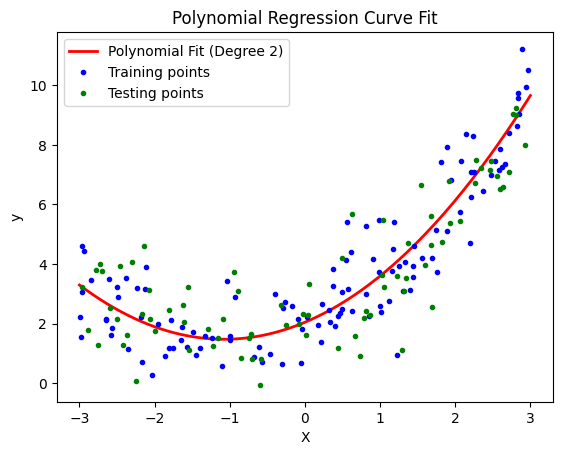

In [25]:

# 1. Smooth plotting ke liye sorted points generate karein
X_new = np.linspace(-3, 3, 200).reshape(-1, 1)

# 2. X_new ko degree-2 mein transform karein
X_new_trans = poly.transform(X_new)

# 3. Model se curve predict karwayen
y_new = lr.predict(X_new_trans)

# 4. Plotting
plt.plot(X_new, y_new, color='r', linewidth=2, label="Polynomial Fit (Degree 2)")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Polynomial Regression Curve Fit")
plt.show()

### **Polynomial Fit Evaluation & Visualization**

1. **Performance Improvement:**
   * Baseline Linear Regression $R^2$: **~0.50**
   * Polynomial Regression (Degree 2) $R^2$: **~0.78** (Drastic improvement in variance explained)

2. **Model Parameter Recovery:**
   * **Learned Coefficients:** $\beta_1 \approx 1.02, \beta_2 \approx 0.59$
   * **Learned Intercept ($\beta_0$):** $\approx 1.60$
   * The model successfully learned the ground truth parabolic structure ($y = 0.5X^2 + X + 2$) from the noisy dataset.

Plotting Technique,Purpose,Result
"plt.scatter(X, y)",Original noisy data points dikhane ke liye.,Scatter dots
np.linspace() + plt.plot(),Mathematical model ki continuous prediction curve dikhane ke liye.,Smooth red curve

# from scratch

In [26]:
import numpy as np

class CustomPolynomialRegression:
    def __init__(self, degree=2):
        self.degree = degree
        self.weights = None  # Intercept aur Coefficients hold karega

    def _create_polynomial_features(self, X):
        """
        Original X ko [1, X, X^2, ..., X^degree] mein convert karta hai
        """
        X_poly = np.ones((X.shape[0], 1))  # Pehla column 1s (Bias) ka
        for d in range(1, self.degree + 1):
            X_poly = np.c_[X_poly, X**d]    # Har degree ki power feature add karta hai
        return X_poly

    def fit(self, X, y):
        # 1. Features transform karein
        X_poly = self._create_polynomial_features(X)

        # 2. Normal Equation apply karein: beta = (X_T * X)^(-1) * X_T * y
        self.weights = np.linalg.inv(X_poly.T.dot(X_poly)).dot(X_poly.T).dot(y)

    def predict(self, X):
        # 1. Test X ko transform karein
        X_poly = self._create_polynomial_features(X)

        # 2. Dot product se prediction nikaalein: y_hat = X_poly * weights
        return X_poly.dot(self.weights)

In [27]:
# 1. Custom model initialize karein
custom_poly = CustomPolynomialRegression(degree=2)

# 2. Model ko training data par fit karein
custom_poly.fit(X_train, y_train)

# 3. Test data par predictions lein
y_pred_custom = custom_poly.predict(X_test)

# 4. Results check karein
print("Custom Model R2 Score:", r2_score(y_test, y_pred_custom))
print("\nLearned Weights (Intercept, Beta1, Beta2):")
print(custom_poly.weights)

Custom Model R2 Score: 0.734152057041343

Learned Weights (Intercept, Beta1, Beta2):
[[2.04705167]
 [1.05970504]
 [0.49218541]]


Yeh function aapke raw feature $X$ ko polynomial features ($1, X, X^2, \dots, X^{\text{degree}}$) wali multi-column matrix mein badalta hai.

Aayein iski ek ek line ko detail mein samajhte hain:

---

### **1. Function Header & Signature**

```python
def _create_polynomial_features(self, X):

```

* **`self`:** Class ke instances (jaise `self.degree`) ko access karne ke liye hai.
* **`_` (Underscore):** Single underscore ka matlab hota hai ke yeh ek **Internal Helper Method** hai. Isey class ke andar dusre methods (jaise `fit` aur `predict`) use karenge, user ko direct call karne ki zaroorat nahi hoti.
* **`X`:** Aapka original 1D ya 2D input array (jiski shape `(N, 1)` hoti hai, jahan $N$ total rows/data points hain).

---

### **2. Intercept / Bias Column Banana**

```python
X_poly = np.ones((X.shape[0], 1))

```

* **`X.shape[0]`:** Yeh data points ki total ginti (rows) batata hai (e.g., agar 120 training points hain, toh `X.shape[0] = 120`).
* **`np.ones((120, 1))`:** Yeh $120 \times 1$ ki ek aisi matrix banata hai jisme **saare values $1$ (ones)** hoti hain.
* **Kyun zaroori hai?** Mathematical equation $y = \boldsymbol{\beta_0 (1)} + \beta_1 X + \beta_2 X^2$ mein $\beta_0$ (Intercept) ke sath $1$ multiply hota hai. Yeh pehla column wahi $1\text{s}$ provide karta hai.

---

### **3. Loop Se Powers ($X^1, X^2, \dots$) Add Karna**

```python
for d in range(1, self.degree + 1):
    X_poly = np.c_[X_poly, X**d]

```

* **`range(1, self.degree + 1)`:** Agar `degree = 2` hai, toh yeh loop $d = 1$ aur $d = 2$ ke liye 2 baar chalega.
* **`X**d`:** $X$ ke har element ki power $d$ nikalta hai:
* **1st Iteration ($d=1$):** $X^1 = X$ (Original values)
* **2nd Iteration ($d=2$):** $X^2$ (Squared values)


* **`np.c_[X_poly, X**d]`:** `np.c_` (column-wise concatenation) pehle se majood `X_poly` matrix ke side/right par naya column attach kar deta hai.

---

### **4. Final Return**

```python
return X_poly

```

Loop khatam hone par yeh array transform hokar return hota hai:

$$\mathbf{X} = \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} \xrightarrow{\text{Return}} \mathbf{X}_{\text{poly}} = \begin{bmatrix} 1 & x_1 & x_1^2 \\ 1 & x_2 & x_2^2 \end{bmatrix}$$

---

### **Dry Run Example (Small Numerical Value)**

Maan lein aap ke paas single value $X = [3]$ hai aur `degree = 2`:

1. **Start:** `X_poly = [[1.0]]`
2. **Loop $d=1$:** $3^1 = 3 \implies$ `np.c_` ke baad: `[[1.0, 3.0]]`
3. **Loop $d=2$:** $3^2 = 9 \implies$ `np.c_` ke baad: `[[1.0, 3.0, 9.0]]`
4. **Final Output:** `[[1.0, 3.0, 9.0]]`

Is transformed matrix ko jab hum Normal Equation ($\boldsymbol{\beta} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$) mein daalte hain, toh model curve ke weights calculate kar leta hai!